# Source A — How Much Is In the Shape of an Article

**The question:** how much of a county can be recovered from the *shape* of its
Wikipedia article — how many sections, how long, which ones, in what order, how
far from the county template, and what the characters look like — without
reading a word for meaning?

**Why every number here carries three readings.** Round one reported +0.00269
mean lift for article shape and it was arithmetically correct. It was also
misleading, because the baseline it was measured against controlled for county
size *linearly, in logs*, and an information-free curve on those same size
columns scores +0.01748 through the identical protocol. The number was right;
its framing was invisible. So nothing below is reported in one framing:

- **`r2_alone`** — the block as the only predictor, no controls. How much of a
  county is recoverable from article shape, size and geography included.
- **`lift` (linear)** — over the linear size-plus-state baseline. Comparable to
  §13–§23.
- **`lift` (flexible)** — over the curvature-augmented baseline. The strict
  reading.

**Why a boost lift additionally carries `vs_boost_floor`.** The two learners
are not on equal footing here: the ridge path imputes missing predictor values
inside its pipeline, while the boosting path (HistGradientBoosting) handles
`NaN` natively and never imputes. That difference alone moves boost's own
*baseline* score, so a boost arm's raw lift is dominated by that shift, not by
what the arm adds. `vs_boost_floor` compares an arm to the boost baseline run
through the identical boost pipeline, which is the reading that isolates the
arm's own contribution under that learner.

Two arms are not findings and are labelled so wherever they appear:
`shape_v1` re-scores round one's block as a regression check, and
`size_nonlinear` is the information-free null control that prices the unit.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
DATA, ANALYSIS, OUTPUTS = REPO / "data", REPO / "analysis-output", REPO / "outputs"
SOURCE_A = ANALYSIS / "source-a"

mpl.rcParams.update({"figure.figsize": (11, 5.5), "figure.dpi": 110, "axes.grid": True,
                     "axes.axisbelow": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

profile = pd.read_parquet(DATA / "source_a_shape_profile.parquet")
structure = pd.read_parquet(DATA / "source_a_structure_features.parquet")
feature_stats = json.loads((SOURCE_A / "source_a_shape_profile_stats.json").read_text())
stats = json.loads((SOURCE_A / "source_a_shape_profile_stats_scoring.json").read_text())
scores = pd.read_csv(OUTPUTS / "source_a_shape_profile_scores.csv")
by_pillar = pd.read_csv(OUTPUTS / "source_a_shape_profile_by_pillar.csv")

profile_cols = [c for c in profile.columns if c != "fips_code"]
v1_cols = [c for c in structure.columns if c != "fips_code"]

print(f"{feature_stats['n_counties']:,} counties")
print(f"shape_v1 {stats['n_shape_v1_features']} cols + profile {stats['n_shape_profile_features']} "
      f"= shape_v2 {stats['n_shape_v2_features']} cols, vs typed {stats['n_typed_features']}")
print(f"{stats['n_targets']} targets | modal skeleton: {len(feature_stats['modal_title_set'])} titles")

3,144 counties
shape_v1 64 cols + profile 73 = shape_v2 137 cols, vs typed 29
28 targets | modal skeleton: 14 titles


## Part one — the four new families

Round one measured how many sections an article has, how long they are, and
which titles are present. These four families measure things it never looked at.

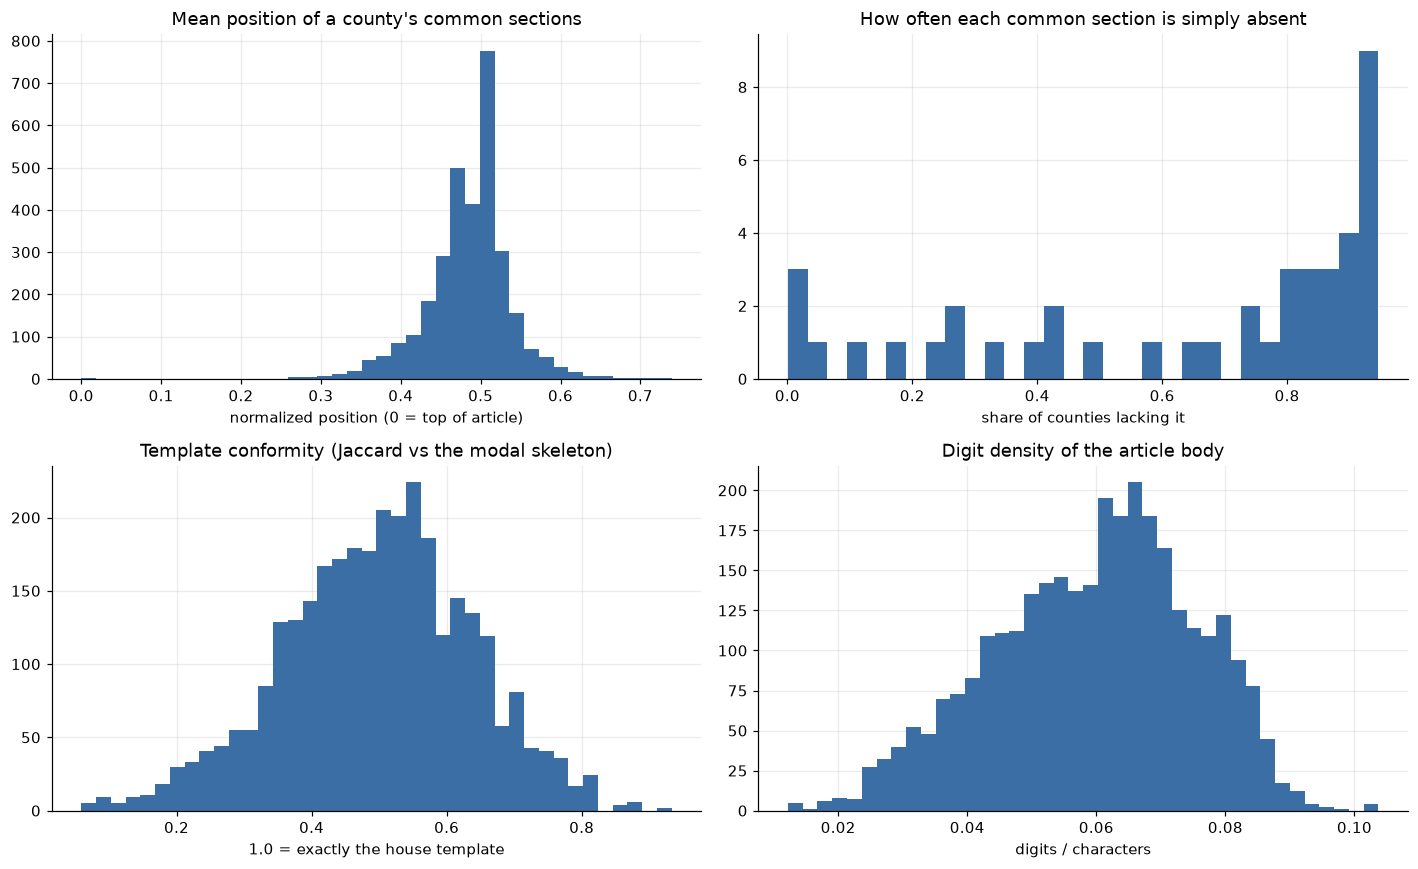

median template conformity 0.500; median digit density 0.061
history precedes economy in 19.1% of counties


In [2]:
POSITION_ABSENT = feature_stats["position_absent_sentinel"]
pos_cols = [c for c in profile_cols if c.startswith("pos_") and not c.startswith("pos_first_")
            and c != "pos_longest_section"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

present = profile[pos_cols].replace(POSITION_ABSENT, np.nan)
axes[0, 0].hist(present.mean(axis=1).dropna(), bins=40, color="#3b6ea5")
axes[0, 0].set_title("Mean position of a county's common sections")
axes[0, 0].set_xlabel("normalized position (0 = top of article)")

absent_share = (profile[pos_cols] == POSITION_ABSENT).mean().sort_values()
axes[0, 1].hist(absent_share, bins=30, color="#3b6ea5")
axes[0, 1].set_title("How often each common section is simply absent")
axes[0, 1].set_xlabel("share of counties lacking it")

axes[1, 0].hist(profile["template_jaccard"], bins=40, color="#3b6ea5")
axes[1, 0].set_title("Template conformity (Jaccard vs the modal skeleton)")
axes[1, 0].set_xlabel("1.0 = exactly the house template")

axes[1, 1].hist(profile["digit_density"], bins=40, color="#3b6ea5")
axes[1, 1].set_title("Digit density of the article body")
axes[1, 1].set_xlabel("digits / characters")

fig.tight_layout()
plt.show()

print(f"median template conformity {profile['template_jaccard'].median():.3f}; "
      f"median digit density {profile['digit_density'].median():.3f}")
print(f"history precedes economy in {profile['history_before_economy'].mean():.1%} of counties")

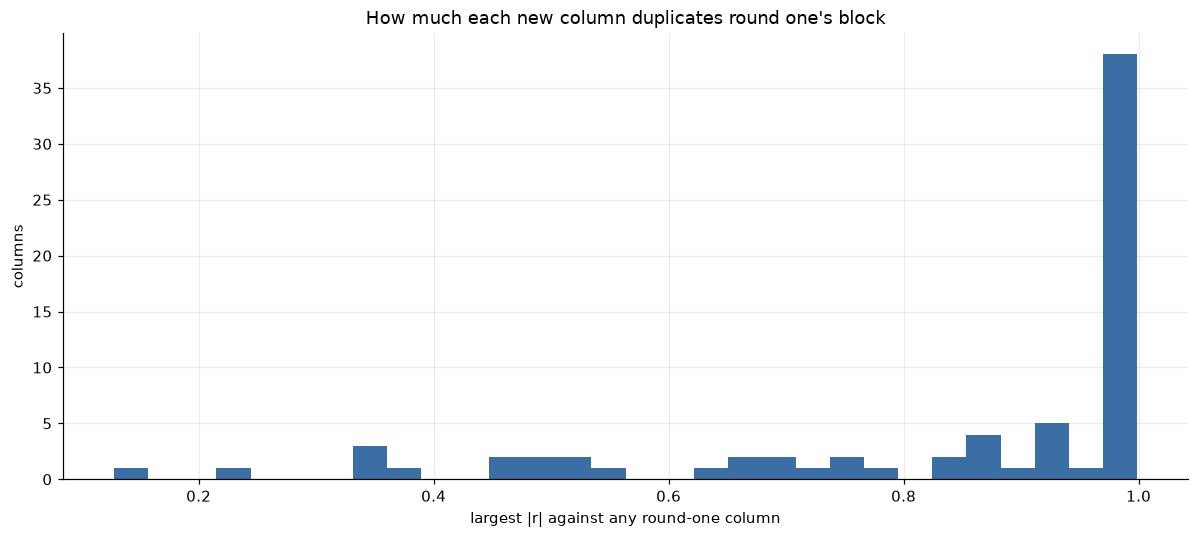

10 of 73 new columns stay under |r| = 0.5 against everything round one already had.
Most duplicated: pos_protected_areas, pos_notable_people, pos_population_ranking
Most novel: digit_density_lists, position_spread, pos_demographics


In [3]:
merged = structure.merge(profile, on="fips_code", validate="one_to_one")
cross = pd.Series(
    {c: merged[v1_cols].corrwith(merged[c]).abs().max() for c in profile_cols}
).sort_values()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(cross, bins=30, color="#3b6ea5")
ax.set_title("How much each new column duplicates round one's block")
ax.set_xlabel("largest |r| against any round-one column")
ax.set_ylabel("columns")
fig.tight_layout()
plt.show()

print(f"{(cross < 0.5).sum()} of {len(cross)} new columns stay under |r| = 0.5 against everything "
      "round one already had.")
print("Most duplicated:", ", ".join(cross.tail(3).index))
print("Most novel:", ", ".join(cross.head(3).index))

## Part two — how much of county size is *in* the block

§23 closed on an open problem. Its per-column size audit came back clean — no
single structural column is a hidden curved size proxy — while the block as a
whole demonstrably carried size. Both are true: the dependence is **joint across
columns**, and no per-column statistic can see it.

So invert the question. Instead of asking whether each column looks like size,
ask how much of county size the whole block can reconstruct. One number, no
statistics argument, and it bounds how much of any lift below could be size in
disguise.

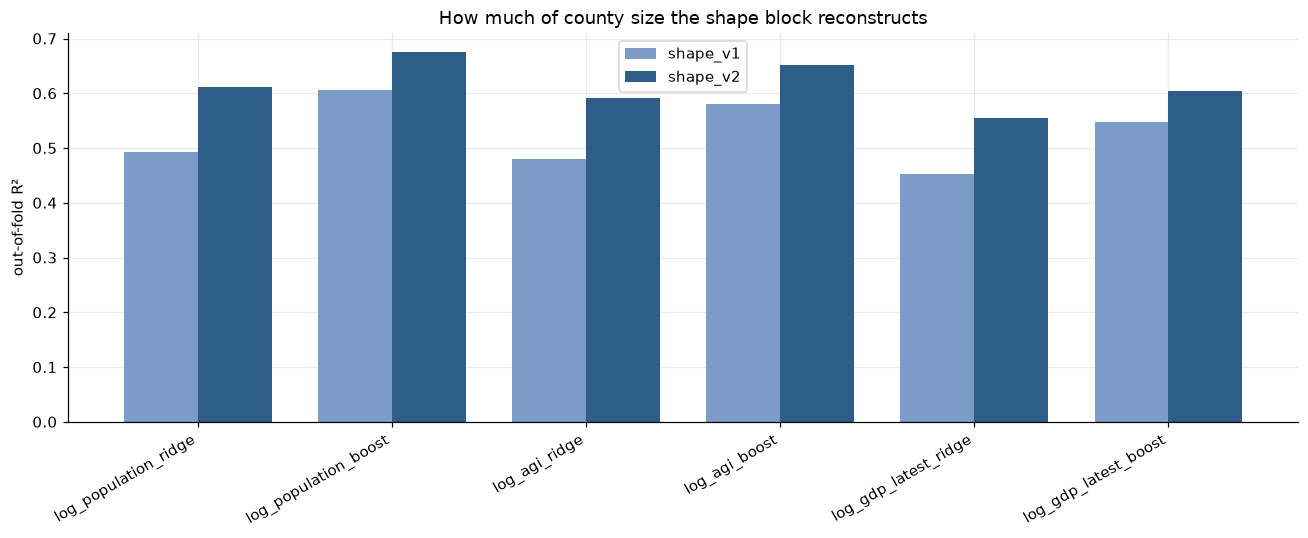

,log_population_ridge,log_population_boost,log_agi_ridge,log_agi_boost,log_gdp_latest_ridge,log_gdp_latest_boost
shape_v1,0.4934,0.606,0.4798,0.5805,0.4528,0.5471
shape_v2,0.6107,0.676,0.5913,0.6509,0.5551,0.6039


Peak: 0.676 — shape_v2 reconstructing log_population_boost.
So article shape encodes county size to R² = 0.676. Any lift below is what remains after a control has already removed size — read it with that in mind.


In [4]:
recovery = pd.DataFrame(stats["size_recoverability"]).T

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(recovery.columns))
width = 0.38
for offset, block, color in zip((-width / 2, width / 2), recovery.index, ("#7a9cc6", "#2f5d8a")):
    ax.bar(x + offset, recovery.loc[block], width, label=block, color=color)
ax.set_xticks(x)
ax.set_xticklabels(recovery.columns, rotation=30, ha="right")
ax.set_ylabel("out-of-fold R²")
ax.set_title("How much of county size the shape block reconstructs")
ax.legend()
fig.tight_layout()
plt.show()

display(recovery.round(4))

peak = recovery.max().max()
where = recovery.stack().idxmax()
print(f"Peak: {peak:.3f} — {where[0]} reconstructing {where[1]}.")
print(f"So article shape encodes county size to R² = {peak:.3f}. Any lift below is what "
      "remains after a control has already removed size — read it with that in mind.")

## Part three — the arms

Five arms, two learners, three framings, and no arm reported in fewer than all
three. `shape_v1` is a regression check on round one's block; `size_nonlinear` is
the information-free null control. Neither is a finding.

**Reading the boost rows.** `lift_linear` and `lift_flexible` are negative for
every boost arm in the table below — that is the boost baseline offset
(`boost_floor`, printed after the table), not the arms failing. `p_vs_floor` is
the reading that actually tests an arm under the boost learner: it compares the
arm to the boost baseline run through the same pipeline, not to the
ridge-baseline zero line the raw lift implies.

In [5]:
def _arm_row(name: str, a: dict) -> dict:
    linear, flexible = a["linear"], a["flexible"]
    row = {
        "arm": name,
        "learner": a["learner"],
        "r2_alone": a["mean_r2_alone"],
        "lift_linear": linear["mean_lift"],
        "p_linear_vs_baseline": linear["vs_baseline"]["wilcoxon_p"],
        "lift_flexible": flexible["mean_lift"],
        "p_flexible_vs_baseline": flexible["vs_baseline"]["wilcoxon_p"],
    }
    if "vs_arm" in linear:
        row["vs_arm"] = linear["vs_arm"]["compared_against"]
        row["p_linear_vs_arm"] = linear["vs_arm"]["wilcoxon_p"]
        row["p_flexible_vs_arm"] = flexible["vs_arm"]["wilcoxon_p"]
    if "vs_boost_floor" in linear:
        row["p_linear_vs_floor"] = linear["vs_boost_floor"]["wilcoxon_p"]
        row["p_flexible_vs_floor"] = flexible["vs_boost_floor"]["wilcoxon_p"]
    return row


arms = pd.DataFrame([_arm_row(name, a) for name, a in stats["arms"].items()])
display(arms.round(5))

floor = stats["boost_floor"]
print(f"boost_floor: linear {floor['linear']['mean_lift']:+.5f}, "
      f"flexible {floor['flexible']['mean_lift']:+.5f} "
      "-- every boost lift above is measured against this, not against zero.")

,arm,learner,r2_alone,lift_linear,p_linear_vs_baseline,lift_flexible,p_flexible_vs_baseline,p_linear_vs_floor,p_flexible_vs_floor,vs_arm,p_linear_vs_arm,p_flexible_vs_arm
0,shape_v1_ridge,ridge,0.08363,0.00269,0.00117,0.00073,0.02805,NaN,NaN,NaN,NaN,NaN
1,shape_v1_boost,boost,0.06259,-0.05867,0.00000,-0.05932,0.00000,0.00009,0.00079,NaN,NaN,NaN
2,shape_v2_ridge,ridge,0.09132,0.00260,0.00129,0.00084,0.00478,NaN,NaN,shape_v1,0.45148,0.45148
3,shape_v2_boost,boost,0.08365,-0.04959,0.00000,-0.05074,0.00000,0.00001,0.00001,shape_v1,0.00266,0.00886
4,typed_ridge,ridge,0.04771,0.00307,0.00038,0.00161,0.01102,NaN,NaN,NaN,NaN,NaN
5,typed_boost,boost,-0.00442,-0.05521,0.00000,-0.05611,0.00000,0.00002,0.00015,NaN,NaN,NaN
6,typed_plus_shape_v2_ridge,ridge,0.10216,0.00513,0.00000,0.00225,0.00155,NaN,NaN,typed,0.05639,0.09002
7,typed_plus_shape_v2_boost,boost,0.09988,-0.04426,0.00000,-0.04688,0.00000,0.00000,0.00000,typed,0.01911,0.01102
8,size_nonlinear_ridge,ridge,0.17064,0.01748,0.00000,0.00000,0.11282,NaN,NaN,NaN,NaN,NaN
9,size_nonlinear_boost,boost,0.11481,-0.03296,0.00097,-0.06146,0.00000,0.00001,0.10925,NaN,NaN,NaN


boost_floor: linear -0.07791, flexible -0.07147 -- every boost lift above is measured against this, not against zero.


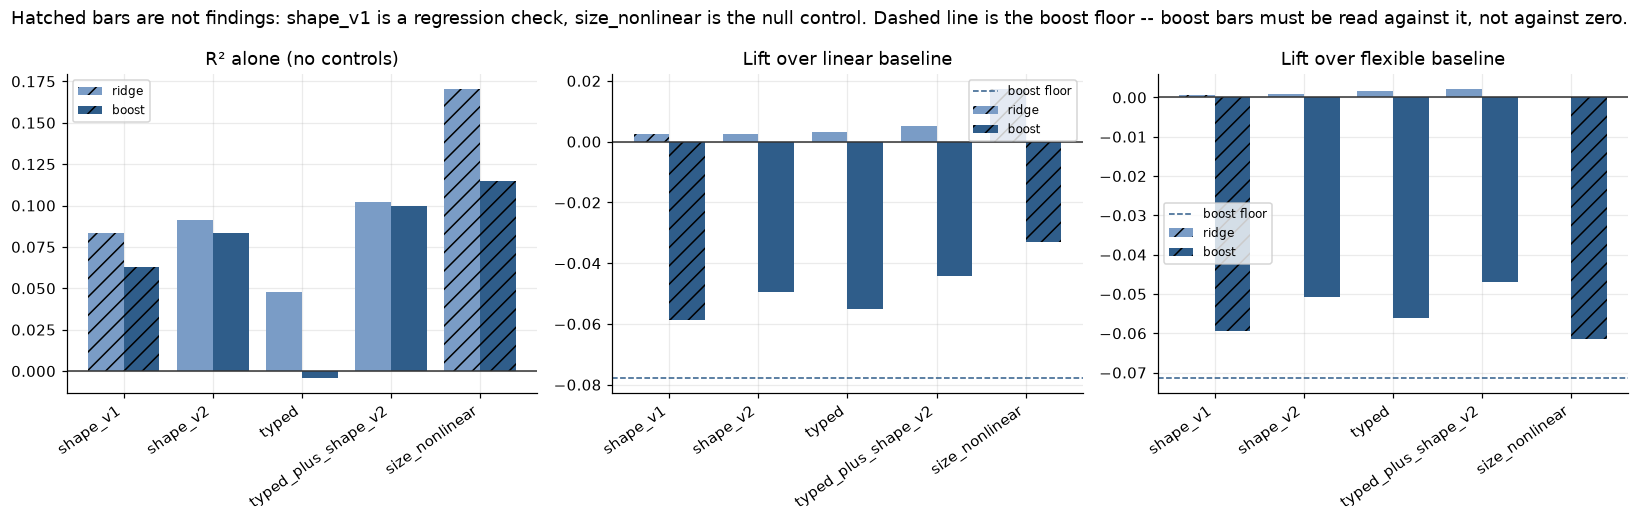

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, column, title in zip(
    axes,
    ("r2_alone", "lift_linear", "lift_flexible"),
    ("R² alone (no controls)", "Lift over linear baseline", "Lift over flexible baseline"),
):
    for offset, learner, color in zip((-0.2, 0.2), ("ridge", "boost"), ("#7a9cc6", "#2f5d8a")):
        subset = arms[arms["learner"] == learner]
        positions = np.arange(len(subset)) + offset
        bars = ax.bar(positions, subset[column], 0.4, label=learner, color=color)
        for bar, arm_name in zip(bars, subset["arm"]):
            if "size_nonlinear" in arm_name or "shape_v1" in arm_name:
                bar.set_hatch("//")
    if column != "r2_alone":
        floor_key = "linear" if column == "lift_linear" else "flexible"
        ax.axhline(stats["boost_floor"][floor_key]["mean_lift"], color="#2f5d8a", lw=1,
                   ls="--", label="boost floor")
    ax.set_xticks(np.arange(len(arms[arms["learner"] == "ridge"])))
    ax.set_xticklabels(
        [n.replace("_ridge", "") for n in arms[arms["learner"] == "ridge"]["arm"]],
        rotation=35, ha="right",
    )
    ax.axhline(0, color="#333", lw=1)
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle("Hatched bars are not findings: shape_v1 is a regression check, "
             "size_nonlinear is the null control. Dashed line is the boost floor -- "
             "boost bars must be read against it, not against zero.")
fig.tight_layout()
plt.show()

### Two questions `shape_v2` answers differently

`shape_v2_ridge` under the linear framing lifts `+0.00260` over the baseline,
`vs_baseline p = 0.0013` — a real, if small, lift over the baseline that never
saw article shape at all. Compared against `shape_v1` instead, the picture
changes: `vs_arm p = 0.4515`, no distinguishable difference. Those are two
different questions — "does shape add anything over no-shape?" (yes) and "does
the round's four new families add anything over round one's block alone?" (no,
not detectably) — and the cell below prints both so neither is quoted without
the other in view.

In [7]:
v2 = stats["arms"]["shape_v2_ridge"]
v1_regression_check = stats["arms"]["shape_v1_ridge"]
print(f"shape_v2_ridge linear: mean_lift={v2['linear']['mean_lift']:+.5f}, "
      f"vs_baseline p={v2['linear']['vs_baseline']['wilcoxon_p']:.4f}, "
      f"vs_arm({v2['linear']['vs_arm']['compared_against']}) "
      f"p={v2['linear']['vs_arm']['wilcoxon_p']:.4f}")
print(f"shape_v1_ridge linear (for comparison): mean_lift={v1_regression_check['linear']['mean_lift']:+.5f}, "
      f"vs_baseline p={v1_regression_check['linear']['vs_baseline']['wilcoxon_p']:.4f}")

shape_v2_ridge linear: mean_lift=+0.00260, vs_baseline p=0.0013, vs_arm(shape_v1) p=0.4515
shape_v1_ridge linear (for comparison): mean_lift=+0.00269, vs_baseline p=0.0012


### Per pillar, because the aggregate is a property of the basket

Twenty of the twenty-eight targets are one QCEW table, so a basket-wide mean is
71% one pillar. Reading it as a breadth claim is a mistake this project has made
before. The chart below is restricted to the ridge columns of `by_pillar` --
boost has no per-pillar floor to read its lifts against, so a per-pillar boost
bar would repeat exactly the framing mistake `vs_boost_floor` exists to avoid.

,pillar,n_targets,shape_v1,shape_v1_boost,shape_v2,shape_v2_boost,typed,typed_boost,typed_plus_shape_v2,typed_plus_shape_v2_boost,size_nonlinear,size_nonlinear_boost
0,B,20,0.00314,-0.06830,0.00287,-0.05861,0.00244,-0.06188,0.00556,-0.05449,0.02010,-0.04412
1,C,3,0.00130,-0.04018,0.00141,-0.03538,0.00180,-0.04574,0.00288,-0.02805,0.00177,-0.04193
2,D,3,0.00000,-0.02621,0.00005,-0.02013,0.00153,-0.04148,0.00055,-0.01444,0.02107,-0.01638
3,E,1,0.00179,-0.03588,0.00152,-0.03150,0.00530,-0.02279,0.00445,-0.02046,0.00001,0.06478
4,F,1,0.00671,-0.04175,0.00946,-0.01847,0.02182,-0.02386,0.01778,-0.00162,0.01892,0.06978


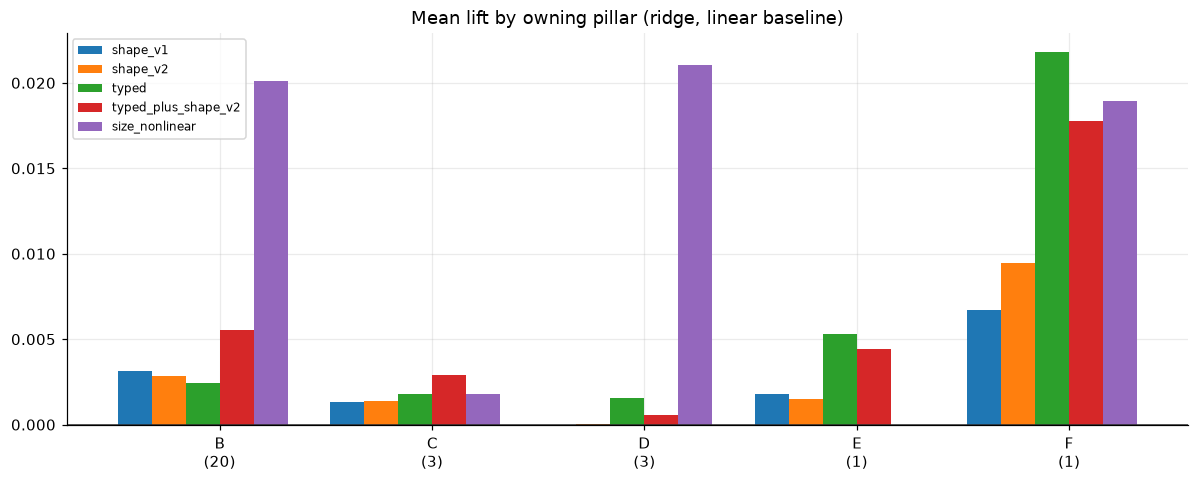

In [8]:
display(by_pillar.round(5))

fig, ax = plt.subplots(figsize=(11, 4.5))
keys = [c for c in by_pillar.columns if c not in ("pillar", "n_targets") and not c.endswith("_boost")]
x = np.arange(len(by_pillar))
width = 0.8 / len(keys)
for i, key in enumerate(keys):
    ax.bar(x + i * width - 0.4, by_pillar[key], width, label=key)
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n({n})" for p, n in zip(by_pillar["pillar"], by_pillar["n_targets"])])
ax.axhline(0, color="#333", lw=1)
ax.set_title("Mean lift by owning pillar (ridge, linear baseline)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Part four — where the ceiling is

The targets article shape predicts best on its own, and what survives as the
control tightens. The gap between the first column and the last is the answer to
"how much of this is really about the article."

,pillar,label,n,r2_alone_shape_v2,r2_alone_shape_v2_boost,lift_shape_v2,lift_shape_v2_flexbase
0,D,freight tonnage (log10),3144,0.4922,0.5481,0.0001,0.0001
1,C,unemployment rate (level),3143,0.2096,0.3015,0.0035,0.0027
2,B,"Agriculture, Forestry, Fishing & Hunting LQ",1457,0.1659,0.1261,-0.0013,0.0000
3,D,inbound partner concentration,3144,0.1486,0.1477,0.0002,0.0000
4,B,Wholesale Trade LQ,2346,0.1399,0.1618,0.0063,0.0018
5,B,"Professional, Scientific & Technical Services LQ",2268,0.1395,0.1018,0.0035,0.0000
6,B,Real Estate & Rental & Leasing LQ,2453,0.1117,0.0727,-0.0020,-0.0021
7,D,outbound partner concentration,3144,0.1091,0.1253,-0.0001,0.0000
8,B,"Mining, Quarrying, Oil & Gas LQ",1026,0.1079,0.1099,-0.0002,0.0004
9,B,Administrative & Support & Waste Management LQ,2212,0.0914,0.0863,-0.0020,-0.0020


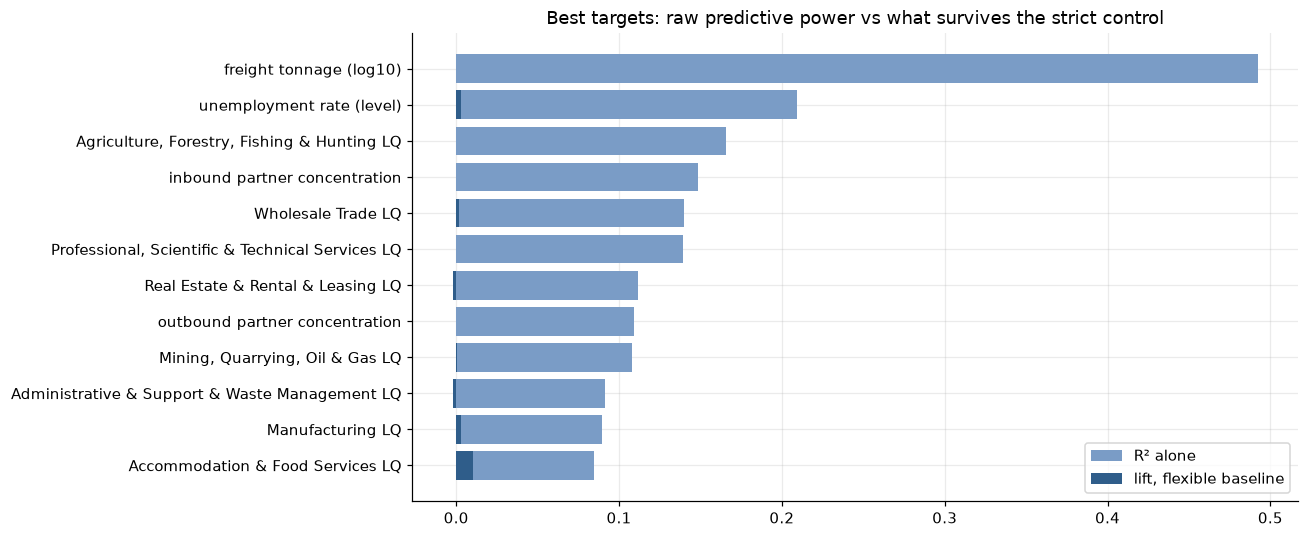

Mean R² alone across all 28 targets: 0.0913
Mean lift over the flexible baseline: +0.00084


In [9]:
ceiling = scores[[
    "pillar", "label", "n",
    "r2_alone_shape_v2", "r2_alone_shape_v2_boost",
    "lift_shape_v2", "lift_shape_v2_flexbase",
]].head(12)
display(ceiling.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
top = scores.head(12).iloc[::-1]
ax.barh(top["label"], top["r2_alone_shape_v2"], color="#7a9cc6", label="R² alone")
ax.barh(top["label"], top["lift_shape_v2_flexbase"], color="#2f5d8a", label="lift, flexible baseline")
ax.set_title("Best targets: raw predictive power vs what survives the strict control")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Mean R² alone across all {stats['n_targets']} targets: "
      f"{scores['r2_alone_shape_v2'].mean():.4f}")
print(f"Mean lift over the flexible baseline: {scores['lift_shape_v2_flexbase'].mean():+.5f}")